
🟢 1. Instalar e baixar dataset


In [1]:
!pip install kagglehub

In [2]:
import kagglehub

# Download dataset
path = kagglehub.dataset_download("ibadeus/pcos-xai-ultrasound-dataset")

print("Dataset path:", path)

Using Colab cache for faster access to the 'pcos-xai-ultrasound-dataset' dataset.
Dataset path: /kaggle/input/pcos-xai-ultrasound-dataset


📁 2. Ajustar caminho das imagens

In [3]:
import os

DATA_DIR = os.path.join(path, "PCOS")
print(os.listdir(DATA_DIR))

['infected', 'noninfected']


🔥 3. Imports

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando:", DEVICE)

Usando: cuda


🖼️ 4. Transformações

In [5]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

📊 5. Dataset + Split

In [6]:
full_dataset = datasets.ImageFolder(DATA_DIR, transform=train_transforms)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# Ajusta transform da validação
val_dataset.dataset.transform = val_transforms

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)

print("Treino:", len(train_dataset))
print("Validação:", len(val_dataset))

Treino: 9427
Validação: 2357


📊 5.1 Distribuição das Classes

> **Por que esse gráfico?** Antes de treinar qualquer modelo, é fundamental verificar se o dataset está balanceado. Um desbalanceamento entre as classes (ex: muito mais imagens `noninfected` do que `infected`) pode fazer o modelo aprender a "chutar" sempre a classe majoritária, inflando a acurácia global sem realmente aprender a diferenciar os casos. Esse gráfico torna esse problema visível logo no início da análise.

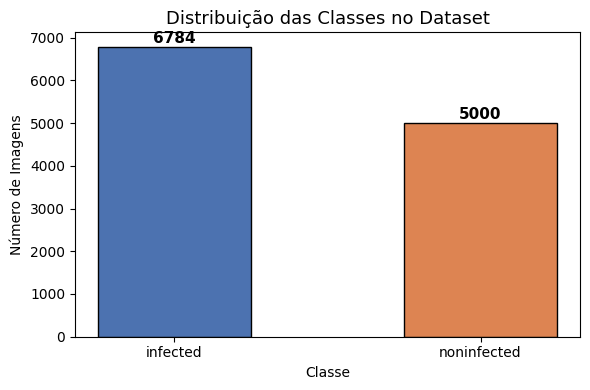

infected: 6784 imagens (57.6%)
noninfected: 5000 imagens (42.4%)


In [7]:
# Conta quantas amostras existem por classe no dataset completo
class_names = full_dataset.classes
class_counts = [full_dataset.targets.count(i) for i in range(len(class_names))]

colors = ['#4C72B0', '#DD8452']

plt.figure(figsize=(6, 4))
bars = plt.bar(class_names, class_counts, color=colors, edgecolor='black', width=0.5)

# Anota a quantidade em cima de cada barra
for bar, count in zip(bars, class_counts):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
             str(count), ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title('Distribuição das Classes no Dataset', fontsize=13)
plt.ylabel('Número de Imagens')
plt.xlabel('Classe')
plt.tight_layout()
plt.show()

total = sum(class_counts)
for name, count in zip(class_names, class_counts):
    print(f"{name}: {count} imagens ({100*count/total:.1f}%)")

🤖 6. Modelo (ResNet18)

In [8]:
model = models.resnet18(pretrained=True)

# Congelar camadas
for param in model.parameters():
    param.requires_grad = False

# Nova camada final
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)

model = model.to(DEVICE)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 44.7M/44.7M [00:00<00:00, 163MB/s]


⚙️ 7. Treinamento

In [9]:
import torch.nn.functional as F

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

EPOCHS = 8

train_losses = []
val_losses = []

# Listas adicionais para acurácia por época
train_accs = []
val_accs = []

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # Calcula acertos no treino
        preds_train = torch.argmax(outputs, dim=1)
        correct_train += (preds_train == labels).sum().item()
        total_train += labels.size(0)

    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)
    train_accs.append(correct_train / total_train)

    model.eval()
    val_loss = 0.0
    all_preds = []
    all_labels = []
    all_probs = []  # probabilidades para a curva ROC

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            # Guarda probabilidade da classe positiva (infected = índice 0)
            probs = F.softmax(outputs, dim=1)[:, 0]
            all_probs.extend(probs.cpu().numpy())

    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    val_acc = sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS} - Train Loss: {train_loss:.4f} - Val Loss: {val_loss:.4f} - Val Acc: {val_acc:.4f}")

Epoch 1/8 - Train Loss: 0.2189 - Val Loss: 0.1190 - Val Acc: 0.9605
Epoch 2/8 - Train Loss: 0.1423 - Val Loss: 0.1043 - Val Acc: 0.9635
Epoch 3/8 - Train Loss: 0.1325 - Val Loss: 0.0833 - Val Acc: 0.9733
Epoch 4/8 - Train Loss: 0.1183 - Val Loss: 0.0723 - Val Acc: 0.9818
Epoch 5/8 - Train Loss: 0.1105 - Val Loss: 0.0684 - Val Acc: 0.9796
Epoch 6/8 - Train Loss: 0.1093 - Val Loss: 0.0673 - Val Acc: 0.9784
Epoch 7/8 - Train Loss: 0.1114 - Val Loss: 0.0716 - Val Acc: 0.9767
Epoch 8/8 - Train Loss: 0.1106 - Val Loss: 0.0630 - Val Acc: 0.9835


📈 8. Avaliação

In [10]:
print("\nRelatório de Classificação:")
print(classification_report(all_labels, all_preds, target_names=["noninfected", "infected"]))


Relatório de Classificação:
              precision    recall  f1-score   support

 noninfected       0.99      0.98      0.99      1348
    infected       0.98      0.99      0.98      1009

    accuracy                           0.98      2357
   macro avg       0.98      0.98      0.98      2357
weighted avg       0.98      0.98      0.98      2357



📊 9. Gráfico — Loss por Época

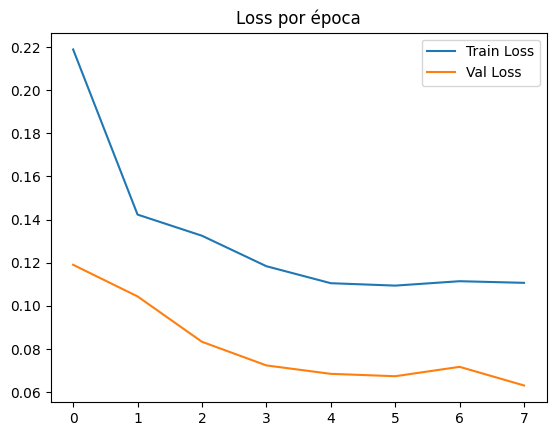

In [11]:
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.title("Loss por época")
plt.show()

📊 10. Acurácia por Época

> **Por que esse gráfico?** Acompanhar a acurácia separadamente da loss permite identificar dois problemas clássicos: **underfitting** (quando treino e validação têm acurácia baixa) e **overfitting** (quando a acurácia de treino sobe, mas a de validação estagna ou cai). No contexto de diagnóstico médico de SOP, um modelo com overfitting pode ter excelente desempenho nos dados de treino, mas falhar em imagens novas — o que é crítico numa aplicação clínica real.

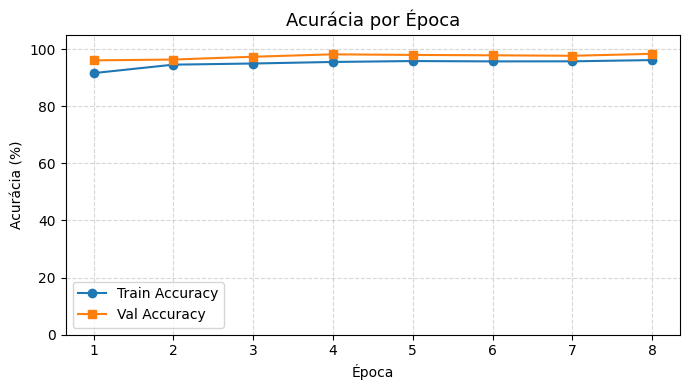

Melhor acurácia de validação: 98.35% (Época 8)


In [12]:
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(7, 4))
plt.plot(epochs_range, [a * 100 for a in train_accs], marker='o', label='Train Accuracy')
plt.plot(epochs_range, [a * 100 for a in val_accs], marker='s', label='Val Accuracy')
plt.title('Acurácia por Época', fontsize=13)
plt.xlabel('Época')
plt.ylabel('Acurácia (%)')
plt.xticks(epochs_range)
plt.ylim(0, 105)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"Melhor acurácia de validação: {max(val_accs)*100:.2f}% (Época {val_accs.index(max(val_accs))+1})")

📊 11. Matriz de Confusão

> **Por que esse gráfico?** A matriz de confusão detalha exatamente onde o modelo erra. No contexto de diagnóstico de SOP, os **falsos negativos** (paciente com SOP classificada como normal) são especialmente graves, pois implicam em diagnóstico perdido e atraso no tratamento. A matriz permite quantificar esses casos e entender se o modelo tem viés para alguma das classes.

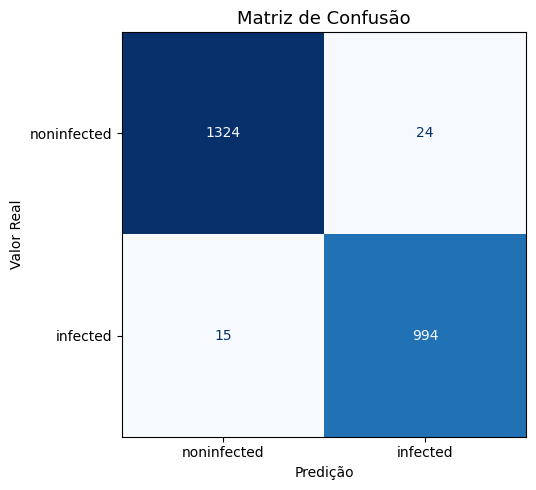

Verdadeiros Positivos (infected correto):   994
Verdadeiros Negativos (noninfected correto): 1324
Falsos Positivos (noninfected como infected): 24
Falsos Negativos (infected como noninfected): 15  ← casos críticos de diagnóstico perdido


In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["noninfected", "infected"])
disp.plot(cmap='Blues', ax=ax, colorbar=False)

ax.set_title('Matriz de Confusão', fontsize=13)
ax.set_xlabel('Predição')
ax.set_ylabel('Valor Real')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"Verdadeiros Positivos (infected correto):   {tp}")
print(f"Verdadeiros Negativos (noninfected correto): {tn}")
print(f"Falsos Positivos (noninfected como infected): {fp}")
print(f"Falsos Negativos (infected como noninfected): {fn}  ← casos críticos de diagnóstico perdido")

📊 12. Curva ROC e AUC

> **Por que esse gráfico?** A curva ROC avalia a capacidade discriminativa do modelo em **todos os limiares de decisão possíveis**, não apenas no limiar padrão de 0.5. O valor de AUC (Área Sob a Curva) é uma métrica amplamente utilizada em diagnóstico clínico: um AUC de 1.0 indica classificação perfeita, enquanto 0.5 equivale a chute aleatório. Isso é especialmente útil em cenários médicos onde pode ser necessário **ajustar o limiar** para priorizar sensibilidade (recall de infected) em detrimento de especificidade.

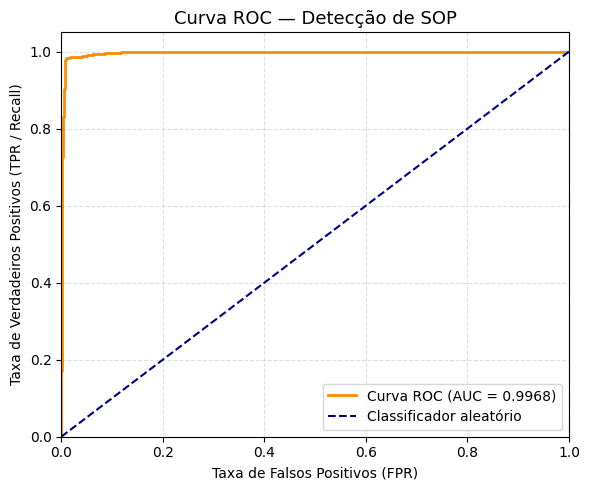

AUC: 0.9968
Excelente poder discriminativo (AUC ≥ 0.99)


In [14]:
from sklearn.metrics import roc_curve, auc

# all_labels: 0 = noninfected, 1 = infected
# all_probs: probabilidade da classe infected (índice 0 no modelo)
# Inverte probabilidade pois o ImageFolder ordeia alfabeticamente: infected=0, noninfected=1
infected_probs = [1 - p for p in all_probs]

fpr, tpr, thresholds = roc_curve(all_labels, infected_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Classificador aleatório')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR / Recall)')
plt.title('Curva ROC — Detecção de SOP', fontsize=13)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

print(f"AUC: {roc_auc:.4f}")
if roc_auc >= 0.99:
    print("Excelente poder discriminativo (AUC ≥ 0.99)")
elif roc_auc >= 0.90:
    print("Ótimo poder discriminativo (AUC entre 0.90 e 0.99)")
else:
    print("Poder discriminativo razoável — considere ajustar o modelo")

## 🔍 13. Predict em Imagem Nova (nunca vista pelo modelo)

> **Por que essa etapa?** Testar o modelo com uma imagem completamente externa ao dataset de treino e validação é a verificação mais próxima de um uso real. Garante que o pipeline de inferência está correto (transformações, device, softmax) e que o modelo generaliza além dos dados que ele conhece. O rótulo real desta imagem é **infected**, permitindo verificar se a predição está correta.

/tmp/ipykernel_3204/1320260287.py:63: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


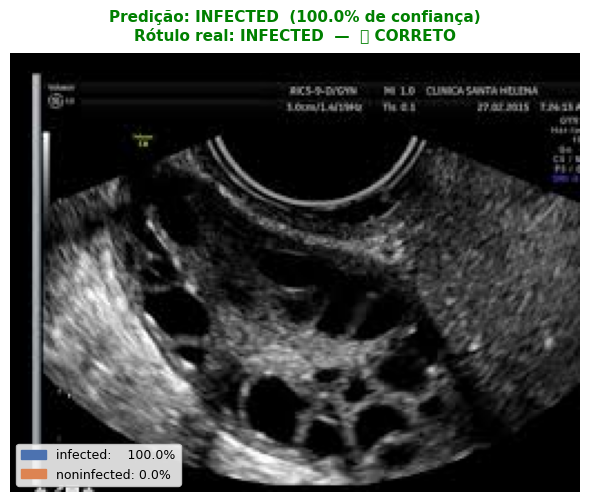


── Resultado do Predict ──
Imagem          : ovario_br_analises.jpg
Rótulo real     : infected
Predição        : infected
Confiança       : 100.00%
  P(    infected): 100.00%
  P( noninfected): 0.00%

Resultado       : ✅ CORRETO


In [15]:
from PIL import Image
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ──────────────────────────────────────────────────
# Ajuste este caminho para o local da sua imagem
# No Colab, faça upload do arquivo e atualize abaixo
# ──────────────────────────────────────────────────
IMG_PATH = "ovario_br_analises.jpg"

# Rótulo real conhecido (para validação manual)
ROTULO_REAL = "infected"

# Mapeamento de índice → nome de classe
# ImageFolder ordena alfabeticamente: infected=0, noninfected=1
idx_to_class = {v: k for k, v in full_dataset.class_to_idx.items()}

# ── Carrega e pré-processa a imagem ──
img_pil = Image.open(IMG_PATH).convert("RGB")

img_tensor = val_transforms(img_pil).unsqueeze(0).to(DEVICE)  # shape: [1, 3, 224, 224]

# ── Inferência ──
model.eval()
with torch.no_grad():
    output = model(img_tensor)
    probs = F.softmax(output, dim=1)[0]

pred_idx = torch.argmax(probs).item()
pred_label = idx_to_class[pred_idx]
confidence = probs[pred_idx].item() * 100

# ── Exibição ──
acertou = pred_label == ROTULO_REAL
cor_borda = "green" if acertou else "red"
status = "✅ CORRETO" if acertou else "❌ INCORRETO"

fig, ax = plt.subplots(figsize=(6, 5))
ax.imshow(img_pil)
ax.axis("off")

titulo = (
    f"Predição: {pred_label.upper()}  ({confidence:.1f}% de confiança)\n"
    f"Rótulo real: {ROTULO_REAL.upper()}  —  {status}"
)
ax.set_title(titulo, fontsize=11, color=cor_borda, fontweight="bold", pad=10)

# Borda colorida ao redor da imagem
for spine in ax.spines.values():
    spine.set_edgecolor(cor_borda)
    spine.set_linewidth(4)

# Legenda com probabilidades de cada classe
patches = [
    mpatches.Patch(color='#4C72B0', label=f"infected:    {probs[0].item()*100:.1f}%"),
    mpatches.Patch(color='#DD8452', label=f"noninfected: {probs[1].item()*100:.1f}%"),
]
ax.legend(handles=patches, loc='lower left', fontsize=9,
          framealpha=0.85, facecolor='white')

plt.tight_layout()
plt.show()

# ── Resumo textual ──
print("\n── Resultado do Predict ──")
print(f"Imagem          : {IMG_PATH}")
print(f"Rótulo real     : {ROTULO_REAL}")
print(f"Predição        : {pred_label}")
print(f"Confiança       : {confidence:.2f}%")
for i, name in idx_to_class.items():
    print(f"  P({name:>12}): {probs[i].item()*100:.2f}%")
print(f"\nResultado       : {status}")

## 📊 14. Distribuição das Classes — Treino vs Validação

> **Por que esse gráfico?** Após o `random_split`, é importante confirmar que a proporção entre as classes se manteve similar nos dois conjuntos. Se o split aleatorio concentrar muito `infected` no treino e pouco na validação (ou vice-versa), as métricas de validação deixam de ser representativas do desempenho real do modelo.

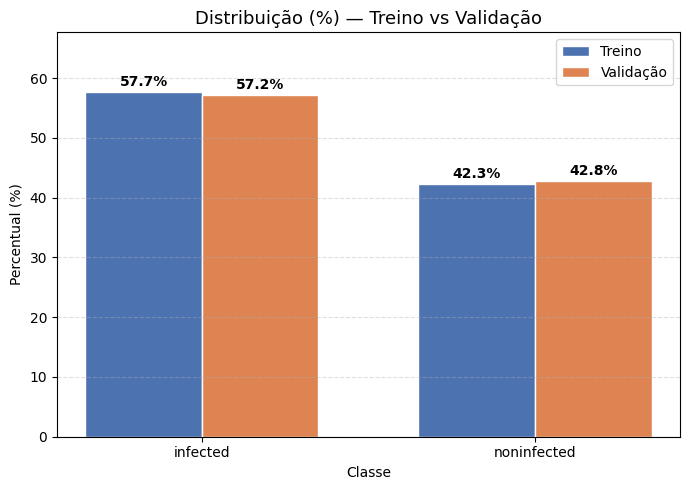

Classe         Treino (n)  Treino (%)   Val (n)   Val (%)
----------------------------------------------------------
infected             5436       57.7%      1348      57.2%
noninfected          3991       42.3%      1009      42.8%
----------------------------------------------------------
TOTAL                9427      100.0%      2357     100.0%


In [16]:
import numpy as np
import matplotlib.pyplot as plt

# ── Coleta os labels de cada split ──
train_labels = [full_dataset.targets[i] for i in train_dataset.indices]
val_labels   = [full_dataset.targets[i] for i in val_dataset.indices]

class_names = full_dataset.classes  # ['infected', 'noninfected']
n_classes   = len(class_names)

# Percentual de cada classe dentro do split
train_pcts = [train_labels.count(i) / len(train_labels) * 100 for i in range(n_classes)]
val_pcts   = [val_labels.count(i)   / len(val_labels)   * 100 for i in range(n_classes)]

# ── Plot ──
x     = np.arange(n_classes)
width = 0.35

fig, ax = plt.subplots(figsize=(7, 5))

bars_train = ax.bar(x - width/2, train_pcts, width, label='Treino',    color='#4C72B0', edgecolor='white')
bars_val   = ax.bar(x + width/2, val_pcts,   width, label='Validação', color='#DD8452', edgecolor='white')

# Anotações de valor em cima de cada barra
for bar, value in zip(bars_train, train_pcts):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f'{value:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

for bar, value in zip(bars_val, val_pcts):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f'{value:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Distribuição (%) — Treino vs Validação', fontsize=13)
ax.set_ylabel('Percentual (%)')
ax.set_xlabel('Classe')
ax.set_xticks(x)
ax.set_xticklabels(class_names)
ax.set_ylim(0, max(max(train_pcts), max(val_pcts)) + 10)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# ── Resumo textual ──
print(f"{'Classe':<14} {'Treino (n)':>10} {'Treino (%)':>11} {'Val (n)':>9} {'Val (%)':>9}")
print("-" * 58)
for i, name in enumerate(class_names):
    tn = train_labels.count(i)
    vn = val_labels.count(i)
    print(f"{name:<14} {tn:>10}  {train_pcts[i]:>9.1f}%  {vn:>8}  {val_pcts[i]:>8.1f}%")
print("-" * 58)
print(f"{'TOTAL':<14} {len(train_labels):>10}  {'100.0%':>10}  {len(val_labels):>8}  {'100.0%':>9}")